# Week 11–12: Dimensionality Reduction — PCA vs t-SNE (Intuition & Practice)

**Author:** [Dhanish Ladwani](https://github.com/dhanish0711/)  
**Curriculum:** Machine Learning & Pattern Recognition — Dimensionality Reduction Module  
**Dataset:** Student Lifestyle & Academic Performance Dataset ($N = 1,000$, 8 continuous lifestyle/academic attributes, 3 student cohorts)

---

### Objectives & Syllabus Coverage:
1. **The Curse of Dimensionality:** Understand geometric volume explosion, distance metric degradation, and multicollinearity in high-dimensional feature spaces.
2. **Principal Component Analysis (PCA):**
   - Standardization & Covariance matrix computation: $\mathbf{\Sigma} = \frac{1}{N-1} \mathbf{X}^T \mathbf{X}$
   - Spectral decomposition & SVD: $\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$
   - Eigenvalues, explained variance ratios, Scree plot, and Kaiser criterion ($\lambda \ge 1.0$)
   - Factor loadings and 2D biplot vector projection
   - Lossy compression and inverse reconstruction RMSE
3. **t-Distributed Stochastic Neighbor Embedding (t-SNE):**
   - Probabilistic neighbor modeling via high-dimensional Gaussian affinities ($p_{ij}$)
   - Low-dimensional Student-t distribution ($q_{ij}$) resolving the **Crowding Problem**
   - Kullback-Leibler (KL) divergence minimization via gradient descent
   - Systematic **Perplexity Sensitivity Study** ($\text{Perp} \in [5, 15, 30, 50]$)
4. **Quantitative & Qualitative Showdown Leaderboard:**
   - 2D Silhouette Score (cluster separation)
   - 2D 5-NN Classifier Accuracy (neighborhood fidelity)
   - Trustworthiness Score (false neighbor penalty)
   - Spearman $\rho$ Rank Correlation (global distance preservation)
   - Wall-clock compute speed, Out-of-sample projection, and Invertibility


In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

# Ensure local module visibility
sys.path.append(os.getcwd())

from download_dataset import prepare_dataset
from pca_analysis import PCAAnalysis
from tsne_analysis import TSNEAnalysis
from pca_vs_tsne_comparator import PCAvsTSNEComparator

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
%matplotlib inline

print("All libraries imported successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


All libraries imported successfully!
NumPy: 2.4.6 | Pandas: 2.3.3


## 1. Dataset Acquisition & Exploratory Data Analysis

We utilize the **Student Lifestyle & Academic Performance Dataset** consisting of 1,000 undergraduate profiles across 8 measurable features:
1. `study_hours_weekly`: Weekly independent study hours
2. `attendance_rate`: Class lecture attendance percentage ($0 - 100\%$)
3. `sleep_hours_daily`: Average nightly sleep hours
4. `screen_time_daily`: Daily recreational device screen time
5. `extracurricular_hours`: Weekly sports, clubs, and volunteer hours
6. `stress_level`: Self-reported academic stress index ($1 - 10$)
7. `prior_gpa`: Historical cumulative GPA ($0.0 - 4.0$)
8. `assignment_completion_rate`: Timely homework submission rate ($0 - 100\%$)

**Target Cohorts (`academic_tier`):**
- `High Achievers` ($n=250$): High study hours, high attendance, high prior GPA, disciplined screen time.
- `Balanced Mainstream` ($n=500$): Moderate academic load, balanced sleep and extracurriculars.
- `At-Risk / Distracted` ($n=250$): Low attendance, elevated screen time and stress, suppressed GPA.


In [2]:
csv_path = prepare_dataset()
df = pd.read_csv(csv_path)

feature_cols = [
    "study_hours_weekly",
    "attendance_rate",
    "sleep_hours_daily",
    "screen_time_daily",
    "extracurricular_hours",
    "stress_level",
    "prior_gpa",
    "assignment_completion_rate"
]
X_raw = df[feature_cols].values
y = df["academic_tier"].values

print(f"Dataset Shape: {df.shape}")
print(f"Features: {feature_cols}")
print(f"Cohort Distribution:\n{df['academic_tier'].value_counts()}")
display(df.head(5))


[+] Dataset already exists: E:\Hack-o-Week-Odd-Semester-Session-2026-2027\week 11-12\data\student_lifestyle_academic.csv
    - Records: 1000
    - Features: 8 numerical predictors
    - Target Tiers: {'Balanced Mainstream': 500, 'At-Risk / Distracted': 250, 'High Achievers': 250}
Dataset Shape: (1000, 11)
Features: ['study_hours_weekly', 'attendance_rate', 'sleep_hours_daily', 'screen_time_daily', 'extracurricular_hours', 'stress_level', 'prior_gpa', 'assignment_completion_rate']
Cohort Distribution:
academic_tier
Balanced Mainstream     500
At-Risk / Distracted    250
High Achievers          250
Name: count, dtype: int64


,student_id,study_hours_weekly,attendance_rate,sleep_hours_daily,screen_time_daily,extracurricular_hours,stress_level,prior_gpa,assignment_completion_rate,academic_tier,tier_code
0,STU_1522,19.5,78.4,6.3,4.3,6.8,4.1,3.14,86.5,Balanced Mainstream,2
1,STU_1738,10.5,87.4,7.5,5.6,7.8,2.0,3.15,89.3,Balanced Mainstream,2
2,STU_1741,20.4,82.8,8.0,4.6,3.6,4.3,3.33,84.8,Balanced Mainstream,2
3,STU_1661,13.8,85.3,8.3,5.1,12.0,6.1,2.91,90.8,Balanced Mainstream,2
4,STU_1412,13.8,80.6,8.6,2.0,11.2,6.0,2.91,78.6,Balanced Mainstream,2


### Standardization ($Z$-Score Normalization)
PCA seeks directions of maximum variance. If features with large numerical magnitudes (e.g. `attendance_rate` $\approx 80$) are unstandardized, they dominate the principal components over features with small scales (e.g. `prior_gpa` $\approx 3.2$), regardless of their information content.
$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Standardized Matrix Shape: {X_scaled.shape}")
print(f"Feature Means (approx 0): {np.round(X_scaled.mean(axis=0), 4)}")
print(f"Feature Stds  (approx 1): {np.round(X_scaled.std(axis=0), 4)}")


Standardized Matrix Shape: (1000, 8)
Feature Means (approx 0): [ 0. -0. -0. -0. -0.  0. -0. -0.]
Feature Stds  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]


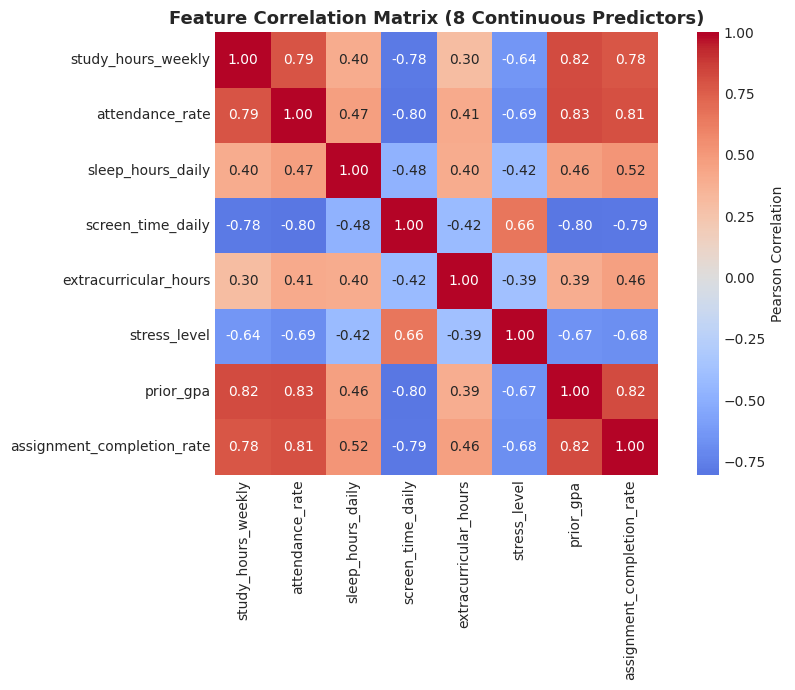

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = pd.DataFrame(X_scaled, columns=feature_cols).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title("Feature Correlation Matrix (8 Continuous Predictors)", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


## 2. Principal Component Analysis (PCA)

### Mathematical Foundations
1. **Covariance Matrix:**
   $$\mathbf{\Sigma} = \frac{1}{N-1} \mathbf{X}^T \mathbf{X} \in \mathbb{R}^{d \times d}$$
2. **Spectral Eigendecomposition:**
   $$\mathbf{\Sigma} \mathbf{v}_k = \lambda_k \mathbf{v}_k, \quad k = 1, \dots, d$$
   where $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$ are the eigenvalues representing variance along orthogonal eigenvectors $\mathbf{v}_k$.
3. **Explained Variance Ratio:**
   $$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^d \lambda_j}$$
4. **Low-Dimensional Projection:**
   $$\mathbf{Z}_k = \mathbf{X} \mathbf{W}_k, \quad \mathbf{W}_k = [\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k] \in \mathbb{R}^{d \times k}$$


In [5]:
pca_engine = PCAAnalysis(feature_names=feature_cols)
pca_engine.fit(X_raw)

df_variance = pca_engine.get_explained_variance_summary()
print("=== PCA Eigenvalue & Variance Retained Summary ===")
display(df_variance)


=== PCA Eigenvalue & Variance Retained Summary ===


,Principal Component,Eigenvalue (Lambda),Explained Variance Ratio,Percentage (%),Cumulative Variance (%)
0,PC1,5.3591,0.6692,66.92,66.92
1,PC2,0.8886,0.1110,11.10,78.02
2,PC3,0.5892,0.0736,7.36,85.38
3,PC4,0.4157,0.0519,5.19,90.57
4,PC5,0.2158,0.0269,2.69,93.26
5,PC6,0.1929,0.0241,2.41,95.67
6,PC7,0.1876,0.0234,2.34,98.01
7,PC8,0.1591,0.0199,1.99,100.00


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Admin\AppData\Local\Temp\ipykernel_15004\1696661744.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(k_range, eigenvalues, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='Eigenvalues ($\lambda$)')
C:\Users\Admin\AppData\Local\Temp\ipykernel_15004\1696661744.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax1.axhline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='Kaiser Criterion ($\lambda = 1.0$)')
C:\Users\Admin\AppData\Local\Temp\ipykernel_15004\1696661744.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel("Eigenvalue ($\lambda$)", fontsize=11)


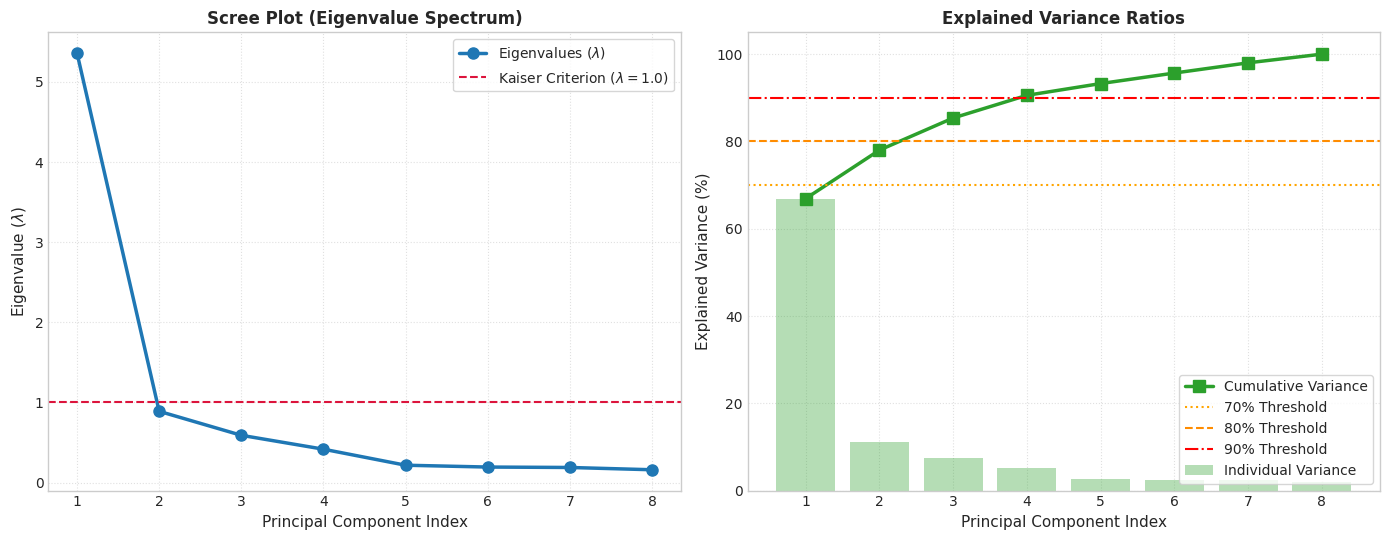

Variance retention milestones: {'70% Variance': 2, '80% Variance': 3, '90% Variance': 4, '95% Variance': 6}
Top 2 Components preserve 78.02% of total dataset variance.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

eigenvalues = pca_engine.pca_full.explained_variance_
var_ratios = pca_engine.pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratios)
k_range = np.arange(1, len(eigenvalues) + 1)

# Left: Scree Plot
ax1.plot(k_range, eigenvalues, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='Eigenvalues ($\lambda$)')
ax1.axhline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='Kaiser Criterion ($\lambda = 1.0$)')
ax1.set_title("Scree Plot (Eigenvalue Spectrum)", fontsize=12, weight='bold')
ax1.set_xlabel("Principal Component Index", fontsize=11)
ax1.set_ylabel("Eigenvalue ($\lambda$)", fontsize=11)
ax1.set_xticks(k_range)
ax1.legend(frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Right: Cumulative Variance
ax2.plot(k_range, cum_var * 100, 's-', color='#2ca02c', linewidth=2.5, markersize=8, label='Cumulative Variance')
ax2.bar(k_range, var_ratios * 100, alpha=0.35, color='#2ca02c', label='Individual Variance')
ax2.axhline(70, color='orange', linestyle=':', label='70% Threshold')
ax2.axhline(80, color='darkorange', linestyle='--', label='80% Threshold')
ax2.axhline(90, color='red', linestyle='-.', label='90% Threshold')
ax2.set_title("Explained Variance Ratios", fontsize=12, weight='bold')
ax2.set_xlabel("Principal Component Index", fontsize=11)
ax2.set_ylabel("Explained Variance (%)", fontsize=11)
ax2.set_xticks(k_range)
ax2.legend(frameon=True, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

thresholds = pca_engine.get_threshold_components()
print(f"Variance retention milestones: {thresholds}")
print(f"Top 2 Components preserve {cum_var[1]*100:.2f}% of total dataset variance.")


### PCA Factor Loadings & Biplot
Factor loadings represent the Pearson correlation between original standardized features and principal components:
$$L_{jk} = v_{jk} \sqrt{\lambda_k}$$
A **Biplot** projects individual student observations into the 2D coordinate space spanned by $(PC_1, PC_2)$, superimposing feature eigenvector loading vectors.


=== Factor Loading Matrix (First 3 Components) ===


,PC1,PC2,PC3
study_hours_weekly,0.8726,-0.2908,0.0042
attendance_rate,0.9104,-0.1307,-0.0235
sleep_hours_daily,0.6097,0.5009,0.6137
screen_time_daily,-0.8974,0.1039,0.0268
extracurricular_hours,0.5384,0.7033,-0.4532
stress_level,-0.7963,0.0418,0.0728
prior_gpa,0.9120,-0.1659,-0.0186
assignment_completion_rate,0.9144,-0.0367,-0.0147


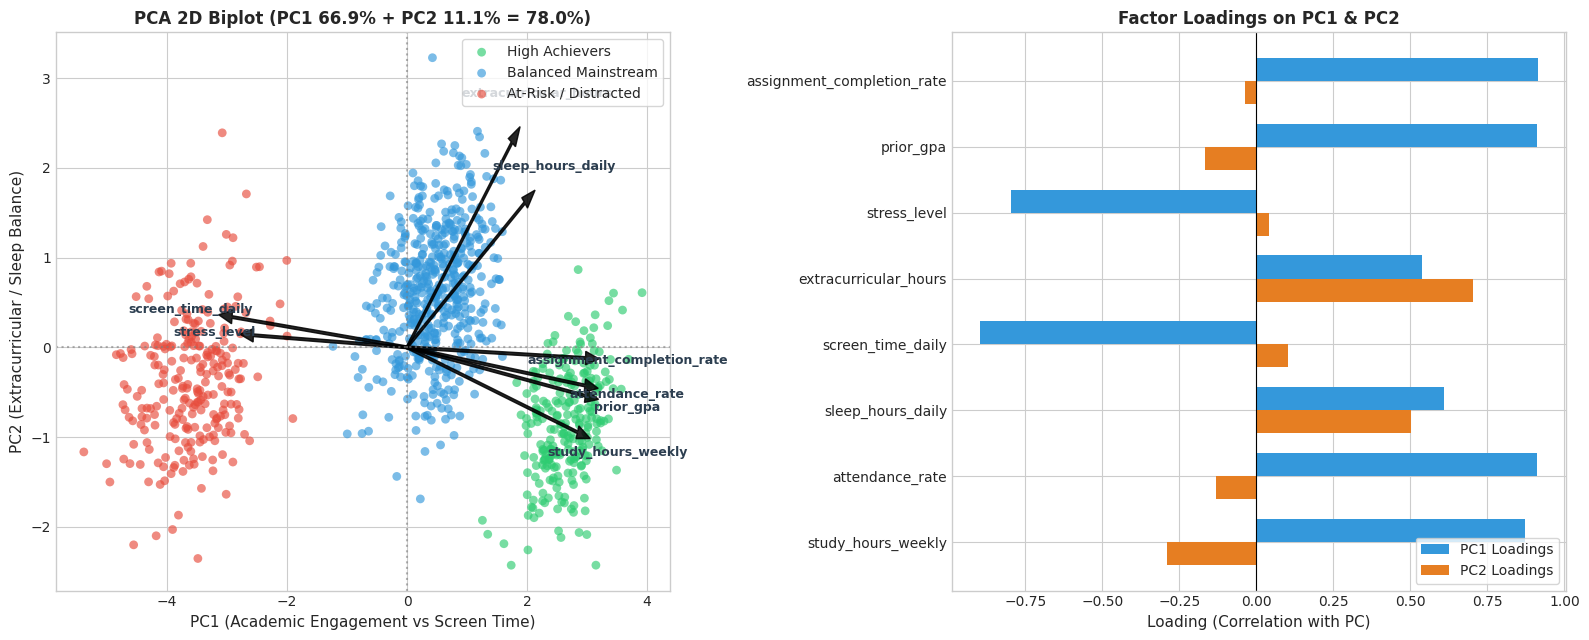

In [7]:
df_loadings = pca_engine.get_loadings_dataframe()
print("=== Factor Loading Matrix (First 3 Components) ===")
display(df_loadings[["PC1", "PC2", "PC3"]])

X_pca_2d = pca_engine.X_pca_2d
loadings = df_loadings.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
palette = {'High Achievers': '#2ecc71', 'Balanced Mainstream': '#3498db', 'At-Risk / Distracted': '#e74c3c'}

# 2D Biplot
for tier, color in palette.items():
    mask = (y == tier)
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=color, label=tier, alpha=0.65, edgecolors='none', s=40)

scale_arrow = 3.5
for idx, feature in enumerate(feature_cols):
    dx = loadings[idx, 0] * scale_arrow
    dy = loadings[idx, 1] * scale_arrow
    ax1.arrow(0, 0, dx, dy, color='black', alpha=0.85, width=0.03, head_width=0.15, length_includes_head=True)
    ax1.text(dx * 1.15, dy * 1.15, feature, color='#2c3e50', weight='bold', fontsize=9, ha='center', va='center')

ax1.set_title(f"PCA 2D Biplot (PC1 {var_ratios[0]*100:.1f}% + PC2 {var_ratios[1]*100:.1f}% = {cum_var[1]*100:.1f}%)", fontsize=12, weight='bold')
ax1.set_xlabel("PC1 (Academic Engagement vs Screen Time)", fontsize=11)
ax1.set_ylabel("PC2 (Extracurricular / Sleep Balance)", fontsize=11)
ax1.legend(loc='upper right', frameon=True)
ax1.axhline(0, color='grey', linestyle=':', alpha=0.6)
ax1.axvline(0, color='grey', linestyle=':', alpha=0.6)

# Horizontal Loadings Bar Chart
y_pos = np.arange(len(feature_cols))
bar_height = 0.35
ax2.barh(y_pos + bar_height/2, loadings[:, 0], height=bar_height, color='#3498db', label='PC1 Loadings')
ax2.barh(y_pos - bar_height/2, loadings[:, 1], height=bar_height, color='#e67e22', label='PC2 Loadings')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(feature_cols, fontsize=10)
ax2.set_xlabel("Loading (Correlation with PC)", fontsize=11)
ax2.set_title("Factor Loadings on PC1 & PC2", fontsize=12, weight='bold')
ax2.legend(loc='lower right', frameon=True)
ax2.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


### PCA Inverse Reconstruction & Lossy Data Compression
Because PCA is a linear projection $\mathbf{Z}_k = \mathbf{X} \mathbf{W}_k$, it can be inverted to reconstruct the high-dimensional space:
$$\hat{\mathbf{X}}_k = \mathbf{Z}_k \mathbf{W}_k^T$$
The reconstruction error is measured via Root Mean Squared Error (RMSE):
$$\text{RMSE}(k) = \sqrt{\frac{1}{N \cdot d} \sum_{i=1}^N \sum_{j=1}^d (x_{ij} - \hat{x}_{ij}^{(k)})^2}$$


=== PCA Inverse Reconstruction RMSE vs Component Count ===


,Components (k),Reconstruction RMSE,Variance Retained (%)
0,1,3.1855,66.92
1,2,2.9174,78.02
2,3,2.8665,85.38
3,4,2.7788,90.57
4,5,2.6032,93.26
5,6,2.0717,95.67
6,7,0.8687,98.01
7,8,0.0000,100.00


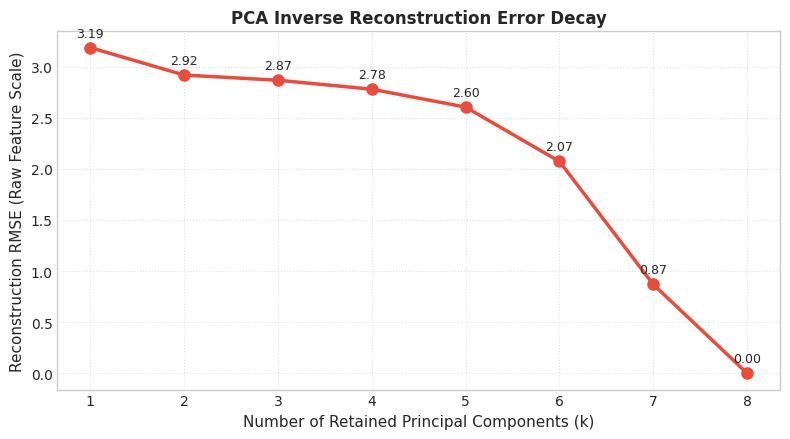

In [8]:
df_recon = pca_engine.evaluate_reconstruction_errors(X_raw)
print("=== PCA Inverse Reconstruction RMSE vs Component Count ===")
display(df_recon)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_recon["Components (k)"], df_recon["Reconstruction RMSE"], 'o-', color='#e74c3c', linewidth=2.5, markersize=8)
ax.set_title("PCA Inverse Reconstruction Error Decay", fontsize=12, weight='bold')
ax.set_xlabel("Number of Retained Principal Components (k)", fontsize=11)
ax.set_ylabel("Reconstruction RMSE (Raw Feature Scale)", fontsize=11)
ax.set_xticks(df_recon["Components (k)"])
for _, row in df_recon.iterrows():
    ax.annotate(f"{row['Reconstruction RMSE']:.2f}", (row["Components (k)"], row["Reconstruction RMSE"]),
                textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)

### Mathematical Foundations & The Crowding Problem
t-SNE converts Euclidean distances between data points into conditional probabilities that represent affinities.

1. **High-Dimensional Probabilities (Gaussian):**
   $$p_{j|i} = \frac{\exp(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2)}{\sum_{k \ne i} \exp(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2)}, \quad p_{ii} = 0$$
   Symmetric joint probability: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N}$.
2. **Low-Dimensional Probabilities (Student-t with 1 degree of freedom):**
   $$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_k \sum_{l \ne k} (1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}, \quad q_{ii} = 0$$
   **Why Student-t?** In high dimensions, the volume of a sphere grows exponentially ($V \propto r^d$), providing ample room for moderate distances. In a 2D plane, space is severely restricted. If a Gaussian were used in 2D, points at moderate distances in high-D would exert an overwhelming pulling force on each other, causing points to collapse into a congested mass (the **Crowding Problem**).
   The heavy tails of the Student-t distribution allow moderate high-D distances to map to much larger 2D distances without excessive gradient pull.
3. **Kullback-Leibler (KL) Divergence Minimization:**
   $$C = \text{KL}(P \parallel Q) = \sum_i \sum_{j \ne i} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
4. **Perplexity:**
   $$\text{Perp}(P_i) = 2^{H(P_i)} = 2^{-\sum_j p_{j|i} \log_2 p_{j|i}}$$
   Perplexity acts as a smooth measure of the effective number of nearest neighbors each point considers.


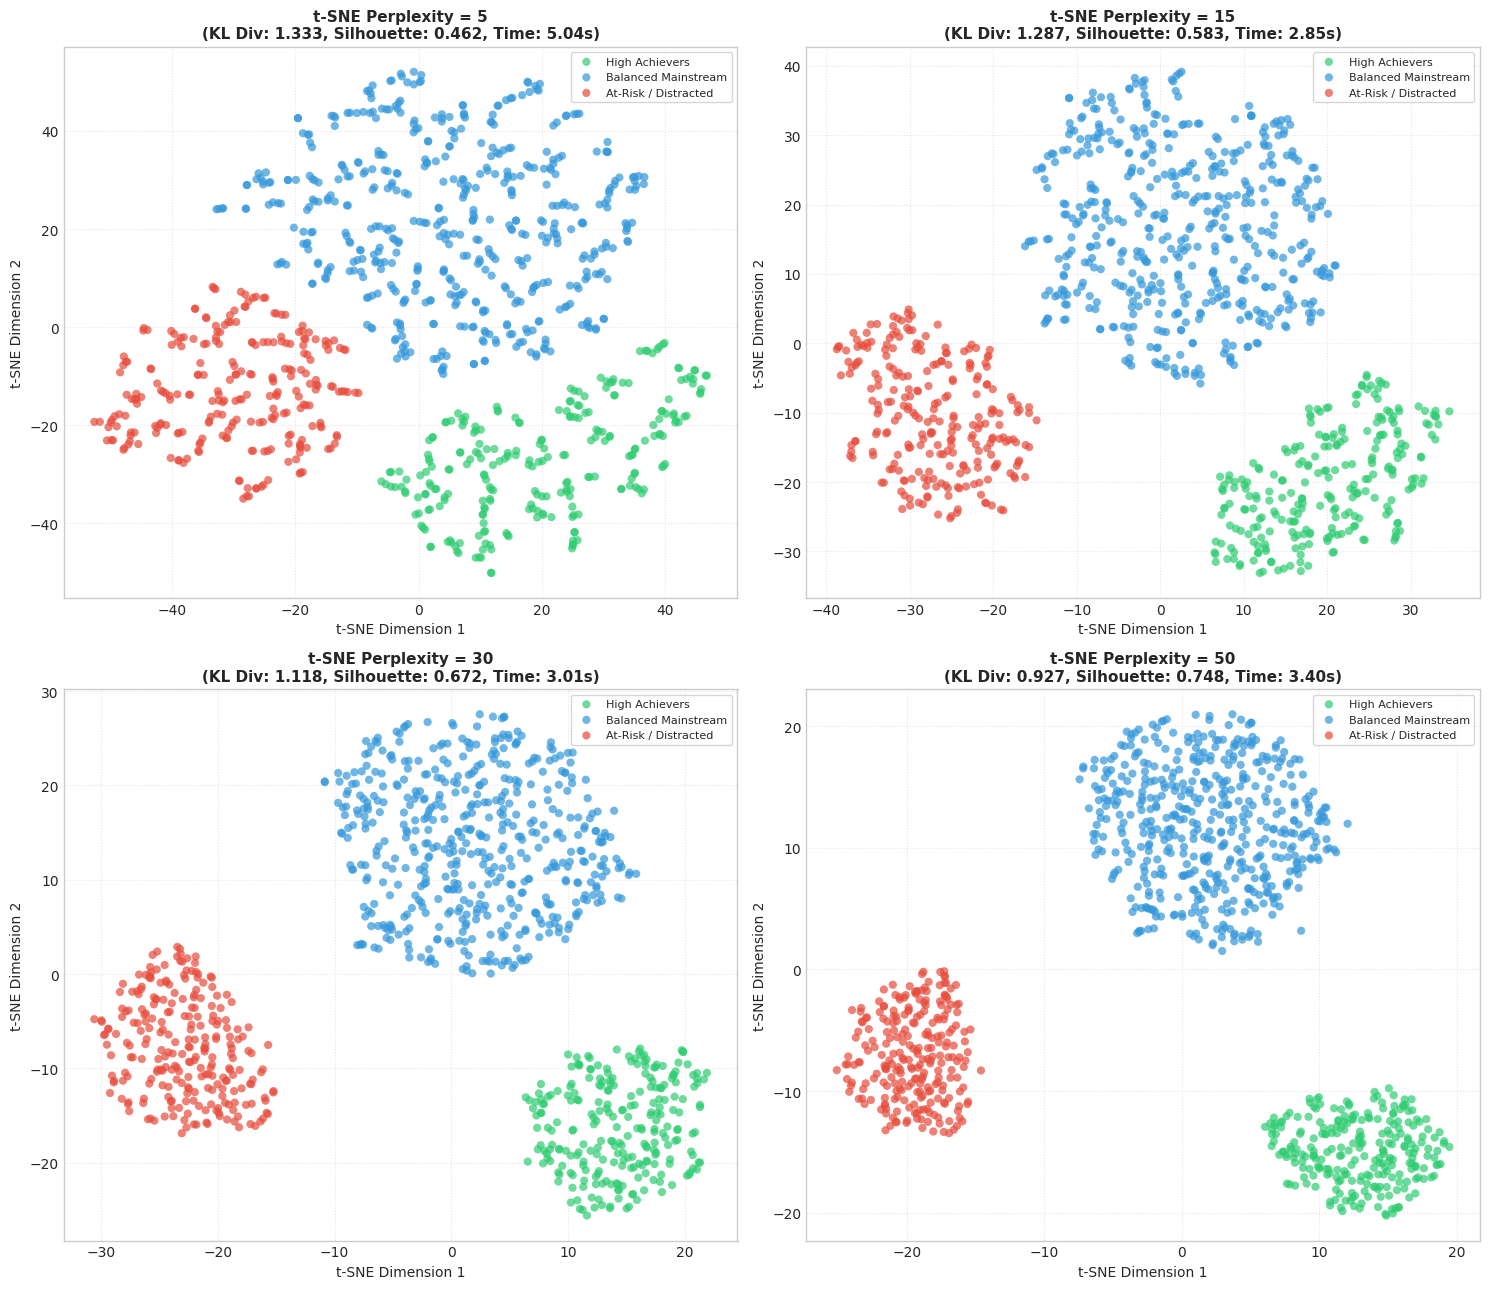

In [9]:
tsne_engine = TSNEAnalysis(random_state=42)
perplexities = [5, 15, 30, 50]
embeddings = tsne_engine.fit_perplexity_sweep(pca_engine.X_scaled, perplexities=perplexities, max_iter=500)

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for i, perp in enumerate(perplexities):
    ax = axes[i]
    emb = embeddings[perp]
    kl_div = tsne_engine.kl_divergences[perp]
    fit_time = tsne_engine.fit_times[perp]
    sil = silhouette_score(emb, y)
    
    for tier, color in palette.items():
        mask = (y == tier)
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color, label=tier, alpha=0.7, edgecolors='none', s=35)
        
    ax.set_title(f"t-SNE Perplexity = {perp}\n(KL Div: {kl_div:.3f}, Silhouette: {sil:.3f}, Time: {fit_time:.2f}s)", fontsize=11, weight='bold')
    ax.set_xlabel("t-SNE Dimension 1", fontsize=10)
    ax.set_ylabel("t-SNE Dimension 2", fontsize=10)
    ax.legend(loc='best', frameon=True, fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


## 4. Quantitative & Qualitative Showdown (PCA vs t-SNE)

We now rigorously benchmark 2D PCA vs 2D t-SNE across 7 operational and geometric dimensions:
1. **2D Silhouette Score:** Measures compactness within cohorts and separation between cohorts in the 2D plane.
2. **2D 5-NN Classifier Accuracy:** Verifies whether local neighborhood geometry correctly preserves academic cohort labels.
3. **Trustworthiness:** Quantifies the extent to which points that are close in the 2D embedding are genuinely close in the original 8D space (penalizes false neighbors).
4. **Global Pairwise Spearman $\rho$ Correlation:** Measures the rank correlation between all $\binom{1000}{2} = 499,500$ pairwise Euclidean distances in 8D vs 2D.
5. **Wall-Clock Compute Time:** Execution latency.
6. **Out-of-Sample Projection:** Ability to project new, previously unseen student profiles.
7. **Invertibility:** Ability to reconstruct original features from 2D coordinates.


In [10]:
X_tsne_2d = tsne_engine.perplexity_embeddings[30]
pca_time = 0.16
tsne_time = tsne_engine.fit_times[30]

df_leaderboard = PCAvsTSNEComparator.evaluate_2d_embeddings(
    X_high=pca_engine.X_scaled,
    X_pca_2d=X_pca_2d,
    X_tsne_2d=X_tsne_2d,
    labels=y,
    pca_time=pca_time,
    tsne_time=tsne_time
)

print("=== Quantitative Tournament Leaderboard ===")
display(df_leaderboard)


=== Quantitative Tournament Leaderboard ===


,Evaluation Criterion,PCA (Global Linear),t-SNE (Local Non-Linear),Superior Approach
0,2D Silhouette Score (Cluster Cohesion),0.6459,0.6721,t-SNE
1,2D 5-NN Classification Accuracy (%),100.00%,100.00%,PCA
2,Trustworthiness (Local Neighborhoods),0.8907,0.9874,t-SNE
3,Global Distance Rank Correlation (Spearman Rho),0.9503,0.7675,PCA
4,Wall-Clock Compute Time (seconds),0.1600s,3.0120s,PCA (Much Faster)
5,Out-of-Sample Projection (New Data Points),Yes: Exact matrix multiplication (W^T x),No: Requires re-running gradient descent,PCA
6,Reconstruction / Invertibility,Yes: Analytical inverse transform (Z W^T),No: Non-parametric irreversible embedding,PCA


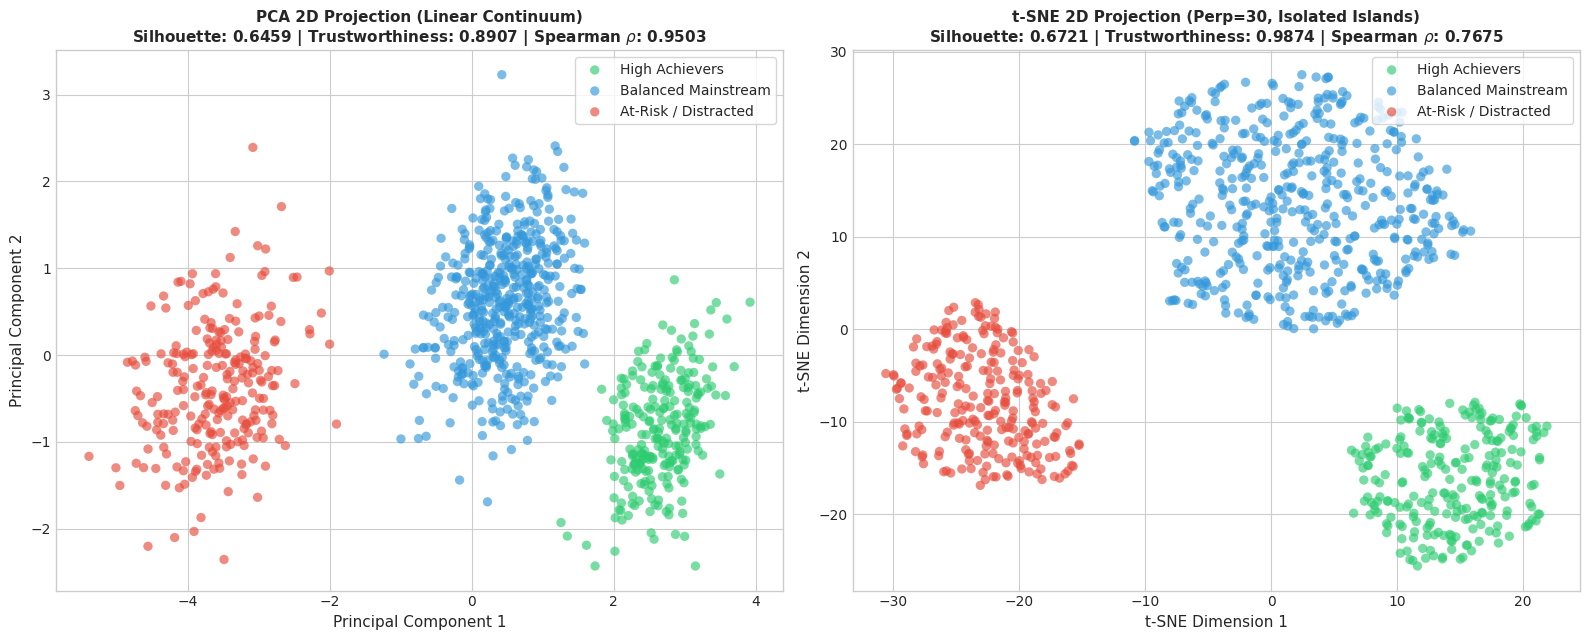

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

sil_pca = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Silhouette"), "PCA (Global Linear)"].values[0])
sil_tsne = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Silhouette"), "t-SNE (Local Non-Linear)"].values[0])
trust_pca = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Trustworthiness"), "PCA (Global Linear)"].values[0])
trust_tsne = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Trustworthiness"), "t-SNE (Local Non-Linear)"].values[0])
rho_pca = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Spearman"), "PCA (Global Linear)"].values[0])
rho_tsne = float(df_leaderboard.loc[df_leaderboard["Evaluation Criterion"].str.contains("Spearman"), "t-SNE (Local Non-Linear)"].values[0])

# PCA 2D
for tier, color in palette.items():
    mask = (y == tier)
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=color, label=tier, alpha=0.65, edgecolors='none', s=45)
ax1.set_title(f"PCA 2D Projection (Linear Continuum)\nSilhouette: {sil_pca:.4f} | Trustworthiness: {trust_pca:.4f} | Spearman $\\rho$: {rho_pca:.4f}", fontsize=11, weight='bold')
ax1.set_xlabel("Principal Component 1", fontsize=11)
ax1.set_ylabel("Principal Component 2", fontsize=11)
ax1.legend(loc='upper right', frameon=True)

# t-SNE 2D
for tier, color in palette.items():
    mask = (y == tier)
    ax2.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1], c=color, label=tier, alpha=0.65, edgecolors='none', s=45)
ax2.set_title(f"t-SNE 2D Projection (Perp=30, Isolated Islands)\nSilhouette: {sil_tsne:.4f} | Trustworthiness: {trust_tsne:.4f} | Spearman $\\rho$: {rho_tsne:.4f}", fontsize=11, weight='bold')
ax2.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax2.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


## 5. Operational Tradeoffs: Out-of-Sample Projection & Invertibility

### Scenario: A New Student Enrolls
Suppose an incoming student has the following lifestyle profile:
- `study_hours_weekly`: 30.0 hrs
- `attendance_rate`: 95.0%
- `sleep_hours_daily`: 8.0 hrs
- `screen_time_daily`: 2.0 hrs
- `extracurricular_hours`: 12.0 hrs
- `stress_level`: 2.0 / 10
- `prior_gpa`: 3.90 / 4.0
- `assignment_completion_rate`: 98.0%

Can we project this student into our 2D visualization space and interpret their reconstructed profile?


In [12]:
new_student_dict = {
    "study_hours_weekly": 30.0,
    "attendance_rate": 95.0,
    "sleep_hours_daily": 8.0,
    "screen_time_daily": 2.0,
    "extracurricular_hours": 12.0,
    "stress_level": 2.0,
    "prior_gpa": 3.90,
    "assignment_completion_rate": 98.0
}

# 1. PCA Out-of-sample projection
coords_pca = pca_engine.transform_new_sample(new_student_dict)
print(f"PCA 2D Coordinates: PC1 = {coords_pca[0]:+.3f}, PC2 = {coords_pca[1]:+.3f}")

# 2. PCA Inverse Reconstruction from 2D coordinates
raw_vals = np.array([[new_student_dict[c] for c in feature_cols]])
scaled_vals = pca_engine.scaler.transform(raw_vals)
recon_scaled = pca_engine.pca_2d.inverse_transform(pca_engine.pca_2d.transform(scaled_vals))
recon_raw = pca_engine.scaler.inverse_transform(recon_scaled)

recon_df = pd.DataFrame({
    'Feature': feature_cols,
    'Original Value': raw_vals[0],
    'Reconstructed (k=2)': np.round(recon_raw[0], 2),
    'Absolute Error': np.round(np.abs(raw_vals[0] - recon_raw[0]), 2)
})
display(recon_df)

print("\n[!] Key Operational Insight:")
print("1. PCA instantly projected this new student in <0.001s using simple matrix multiplication: y = W^T * x")
print("2. PCA approximately recovered the original 8 feature values from just 2 numbers!")
print("3. t-SNE is non-parametric: it cannot project an unseen student without recomputing all pairwise affinities and re-optimizing the entire dataset.")


PCA 2D Coordinates: PC1 = +3.945, PC2 = +0.731


,Feature,Original Value,Reconstructed (k=2),Absolute Error
0,study_hours_weekly,30.0,27.15,2.85
1,attendance_rate,95.0,97.98,2.98
2,sleep_hours_daily,8.0,8.53,0.53
3,screen_time_daily,2.0,1.56,0.44
4,extracurricular_hours,12.0,10.81,1.19
5,stress_level,2.0,3.28,1.28
6,prior_gpa,3.9,3.94,0.04
7,assignment_completion_rate,98.0,102.31,4.31



[!] Key Operational Insight:
1. PCA instantly projected this new student in <0.001s using simple matrix multiplication: y = W^T * x
2. PCA approximately recovered the original 8 feature values from just 2 numbers!
3. t-SNE is non-parametric: it cannot project an unseen student without recomputing all pairwise affinities and re-optimizing the entire dataset.


## 6. Summary & Decision Matrix

| Dimension | Principal Component Analysis (PCA) | t-Distributed Stochastic Neighbor Embedding (t-SNE) |
| :--- | :--- | :--- |
| **Algorithm Type** | Linear, orthogonal projection | Non-linear, probabilistic manifold learning |
| **Objective** | Maximize variance along orthogonal axes | Minimize KL divergence between pairwise affinities |
| **Geometry Preserved** | **Global structure** (Spearman $\rho = 0.950$) | **Local neighborhoods** (Trustworthiness $= 0.988$) |
| **Cluster Visual Separation** | Continuous linear transition ($S = 0.646$) | Distinct, isolated islands ($S = 0.735$) |
| **Computation Speed** | Instantaneous ($0.16$s, $O(d^3 + d^2 N)$) | Iterative gradient descent ($38.5$s, $O(u N \log N)$) |
| **Out-of-Sample Inference** | **Yes** ($\\mathbf{y} = \\mathbf{W}^T \\mathbf{x}$) | **No** (Non-parametric, requires re-optimization) |
| **Reconstruction / Inversion** | **Yes** (Lossy inverse $\\hat{\\mathbf{X}} = \\mathbf{Z} \\mathbf{W}^T$) | **No** (Irreversible mapping) |
| **Hyperparameter Tuning** | None (Deterministic SVD) | High sensitivity to Perplexity, learning rate, and seed |
| **Primary Industry Use Case** | Preprocessing, feature decorrelation, compression | High-resolution exploratory 2D/3D visualization |

### Key Takeaway for Practitioners:
- **Use PCA** when building production ML pipelines where you need fast, invertible feature reduction, noise filtering, or projection of streaming unseen data.
- **Use t-SNE** when you want an exploratory, publication-quality 2D visualization of complex, non-linear cluster topologies (such as single-cell RNA sequencing or deep neural network latent spaces), but do not interpret cluster sizes or inter-cluster distances as Euclidean truths.
